# Spatial Econometrics — do bars drive drunk incidents in San Francisco?

**Companion to deck `05-spatial-dependence` (Part 3 — Strategy 2: Spatial model structure).**

This notebook shows, step by step, how to:
1. Load the **San Francisco block-group** data and read its distribution before modelling.
2. Build the **adjacency matrix** — and compare **Rook** vs **Queen** contiguity.
3. **Audit the graph**: find the block group with 0 neighbours, the one with 35, and a multipart geometry — and decide what to do about each.
4. Turn links into **weights**: binary vs **row-standardised**, and see what the spatial lag $Wy$ actually is.
5. Explore: **scatterplot**, **choropleth**, **global Moran's I**, correlation matrix.
6. Place the models on the **$WY$ / $WX$ / $Wu$ taxonomy** (SLX, SAR, SEM, SDM).
7. Fit **OLS with spatial diagnostics** and let the **robust LM** tests name the missing term.
8. Fit the **whole family** by maximum likelihood and rank it by **AIC**.
9. Fit the **spatial lag model** and check it *actually fixed* the autocorrelation.
10. Decompose $\beta$ into **direct / indirect / total impacts** — by hand, one number at a time.
11. Convert impacts to **elasticities** so the finding is legible to a non-specialist.

> Dataset: `data/incidents/InputDataset.csv` — 580 census block groups with drunk-incident counts,
> bar and retail density, poverty and demographics — joined to
> `data/incidents/SF_BlockGroups10.parquet` (NAD83 / California Albers, EPSG:3310; already metric).
>
> This analysis follows **Andrew Gaidus**, *Modeling San Francisco Crime Rates: A Spatial
> Econometric Approach*, updated to the modern PySAL API and extended with the full model family,
> AIC-based selection, and the exact impact decomposition.

## The question

Bars and drunkenness plainly go together, but *how much* of a neighbourhood's drunk-incident rate
is attributable to **its own** bar density, and how much simply **spills over** from next door?

That distinction is not academic. If a licensing board approves a new bar in one block group, the
consequences may land in the **surrounding** block groups — people drink here and stumble home
there. A model that assigns all the effect to the block group holding the licence will understate
the true cost of the decision.

Standard OLS cannot express this: it assumes each observation is independent, so a change in one
place affects the outcome in *that place only*. Spatial econometrics fixes that by putting the
spatial relationship **inside the equation**. Our job across this notebook is to decide *which*
spatial term the data actually demand, and then to interpret it correctly.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np                  # arrays and linear algebra (we invert a matrix later)
import pandas as pd                 # tabular data
import geopandas as gpd             # tabular data + geometry
import matplotlib.pyplot as plt     # plots

import esda                         # Moran's I (spatial autocorrelation)
import spreg                        # spatial regression: OLS, ML_Lag, ML_Error
from libpysal.graph import Graph    # the modern weights/graph API

%config InlineBackend.figure_format = "retina"

SEED = 42        # fixed seed -> reproducible permutation p-values

Three PySAL packages do the work: **`libpysal.graph`** builds the neighbour graph, **`esda`**
tests for spatial autocorrelation, and **`spreg`** fits the regressions. `SEED` fixes the random
number generator so every permutation-based p-value below is reproducible.

# 1. The data

The attributes and the geometry live in two files. Load them separately, then join.

In [2]:
# The attribute table: one row per census block group.
# BGFIPS10 is the block-group ID -- read it as a string so leading zeros survive.
data = pd.read_csv("data/incidents/InputDataset.csv",
                   dtype={"BGFIPS10": object}).set_index("BGFIPS10")

print(f"{len(data)} rows, {len(data.columns)} columns")
print(list(data.columns))

580 rows, 11 columns
['Drunk', 'DrunkP1k', 'Bars', 'BarPSqMi', 'RetailPSqMi', 'Pop', 'PopDens1k', 'pMale', 'pHHPov', 'VacantHU', 'SqMiles']


580 block groups. `Drunk` is the raw incident count and `DrunkP1k` the rate per 1,000 residents —
we model the **rate**, since raw counts would mostly measure how many people live there.

In [3]:
# The geometry: one polygon per block group.
geo = gpd.read_parquet("data/incidents/SF_BlockGroups10.parquet").set_index("BGFIPS10")

print("CRS:", geo.crs.name)
print("projected (metric)?", geo.crs.is_projected)

CRS: NAD83 / California Albers
projected (metric)? True


The CRS is **NAD83 / California Albers** — a *projected* system measured in metres. That matters:
contiguity does not care about units, but any distance-based weighting would, and a geographic
(degrees) CRS would silently distort them. The data arrive correctly projected, so nothing to fix.

In [4]:
# Join attributes to geometry on the shared index.
gdf = gpd.GeoDataFrame(data, geometry=geo.geometry, crs=geo.crs)

YVar  = "DrunkP1k"                                                  # the outcome
XVars = ["pHHPov", "BarPSqMi", "RetailPSqMi", "pMale", "VacantHU"]  # the predictors

print(f"{len(gdf)} block groups with geometry")
gdf[[YVar] + XVars].head()

580 block groups with geometry


,DrunkP1k,pHHPov,BarPSqMi,RetailPSqMi,pMale,VacantHU
BGFIPS10,,,,,,
060750101001,27.551020,9.859155,9.622053,91.409506,50.204082,5.490849
060750101002,2.809975,16.896985,35.622900,94.994400,55.567264,7.334109
060750102001,11.131725,5.669291,9.787183,58.723099,60.760668,30.219780
060750102002,0.000000,3.139717,0.000000,20.616740,47.673861,5.278810
060750102003,1.892148,7.822686,0.000000,19.759272,51.561022,9.658422


The model we are heading toward:

$$\texttt{DrunkP1k} = \beta_0 + \beta_1\texttt{pHHPov} + \beta_2\texttt{BarPSqMi} +
\beta_3\texttt{RetailPSqMi} + \beta_4\texttt{pMale} + \beta_5\texttt{VacantHU} + \varepsilon$$

- **`BarPSqMi`** — bars per square mile. **The variable of interest.**
- **`pHHPov`** — % households in poverty; **`RetailPSqMi`** — retail density (a proxy for general
  commercial activity, so bar density is not just picking up "busy area"); **`pMale`** — %
  male; **`VacantHU`** — vacant housing units (a rough proxy for physical disorder).

In [5]:
gdf[[YVar] + XVars].describe().round(2)

,DrunkP1k,pHHPov,BarPSqMi,RetailPSqMi,pMale,VacantHU
count,580.00,580.00,580.00,580.00,580.00,580.00
mean,5.49,12.61,18.81,100.67,50.78,7.42
std,27.45,11.58,44.50,146.15,7.32,7.04
min,0.00,0.00,0.00,0.00,25.40,0.00
25%,0.00,4.15,0.00,0.00,46.08,1.62
50%,1.10,9.91,0.00,43.74,50.17,6.14
75%,3.26,17.32,21.32,139.31,54.66,11.15
max,600.00,66.41,344.94,1269.50,75.29,41.85


**Read this before modelling anything.** The outcome is severely **skewed**: the median block
group records **1.1** drunk incidents per 1,000 people, the mean is **5.5**, and the maximum is
**600**. More than a quarter record **zero**.

That is the signature of a count process concentrated in a few nightlife districts, not a tidy
bell curve. We follow the source analysis and fit a linear model to the rate — fine for learning
the spatial machinery, and the spatial conclusions below are robust — but a **Poisson or
negative-binomial** model is the statistically correct home for an outcome like this. We return to
it in the caveats.

**Lesson —** inspect the outcome's distribution before choosing a model: spatial dependence is only
one of the assumptions you are about to make.

# 2. Building the adjacency matrix

Every spatial model rests on one decision made before any estimation: **who is a neighbour?**

The adjacency matrix $W$ encodes it. $W_{ij} \ne 0$ means "$j$ is a neighbour of $i$". Everything
downstream — the spatial lag, Moran's I, $\rho$ — is computed *through* $W$. Get it wrong and every
number after it is wrong.

For polygons the natural rule is **contiguity** (do they touch?), and it comes in two flavours
borrowed from chess:

- **Rook** — polygons must share an **edge**, a stretch of border with length.
- **Queen** — sharing a **single corner point** is enough.

Queen is more generous, so it can never find fewer neighbours than Rook.

In [6]:
# Rook: share an edge.
rook_g = Graph.build_contiguity(gdf, rook=True)

print("Rook graph built.")
print("average neighbours:", round(rook_g.cardinalities.mean(), 2))

Rook graph built.
average neighbours: 5.33


In [7]:
# Queen: sharing a corner is enough.
queen_g = Graph.build_contiguity(gdf, rook=False)

print("Queen graph built.")
print("average neighbours:", round(queen_g.cardinalities.mean(), 2))

Queen graph built.
average neighbours: 6.36


Queen finds slightly more neighbours on average, as it must. Whether the difference *matters* is
an empirical question — let us look at a single block group.

In [8]:
bg = "060750103003"          # an example block group

print(f"Block group {bg}")
print("  rook  neighbours:", len(rook_g[bg]), "->", list(rook_g[bg].index))
print("  queen neighbours:", len(queen_g[bg]), "->", list(queen_g[bg].index))

Block group 060750103003
  rook  neighbours: 4 -> ['060750103002', '060750107001', '060750108001', '060750109001']
  queen neighbours: 7 -> ['060750102002', '060750103002', '060750107001', '060750107002', '060750108001', '060750109001', '060750109002']


For this block group Rook finds **4** neighbours and Queen finds **7** — the three extra ones touch
it only at a corner. Plotting makes the difference obvious.

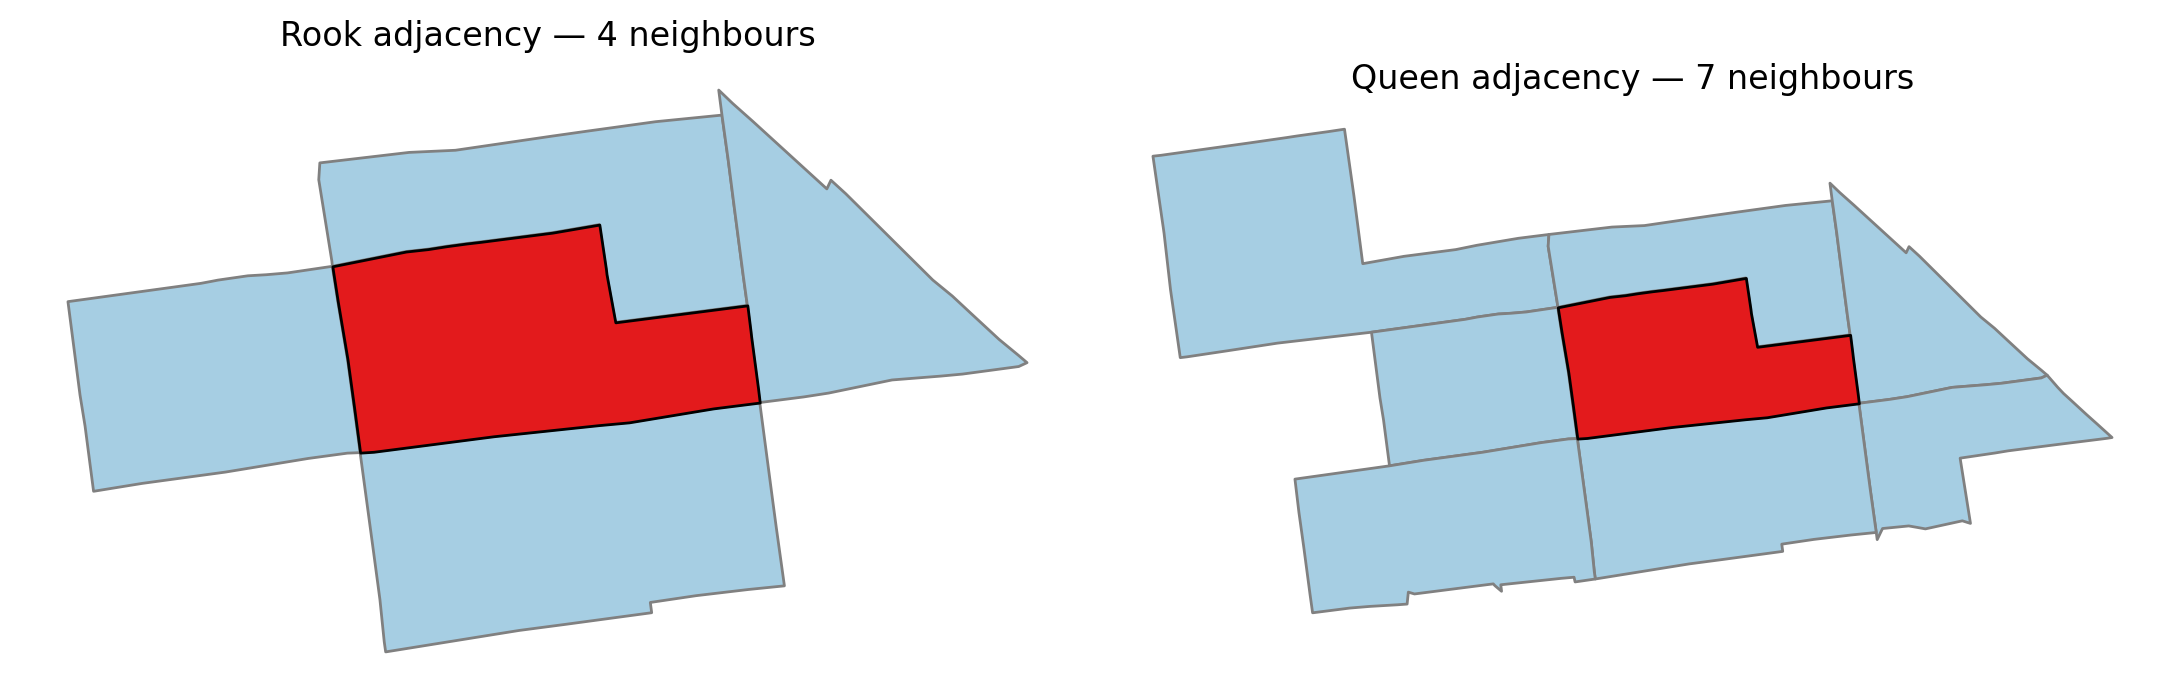

In [9]:
f, ax = plt.subplots(1, 2, figsize=(11, 5))

for a, (name, g) in zip(ax, [("Rook", rook_g), ("Queen", queen_g)]):
    gdf.loc[list(g[bg].index)].plot(ax=a, color="#a6cee3", edgecolor="grey")  # neighbours
    gdf.loc[[bg]].plot(ax=a, color="#e31a1c", edgecolor="k")                  # the target
    a.set_title(f"{name} adjacency — {len(g[bg])} neighbours")
    a.set_axis_off()

plt.tight_layout(); plt.show()

Red is the target block group, blue are its neighbours. The Queen panel picks up polygons that
merely touch a corner of the red one.

**We use Queen from here on.** For irregular administrative units, a shared corner still plausibly
means "next to" — two block groups meeting at a street intersection are neighbours in any
meaningful sense — and Queen avoids the arbitrary knife-edge of whether a boundary segment has
length. It is also the field's usual default, which makes results comparable.

**Lesson —** the neighbour rule is an assumption, not a fact. State which one you used, and be
prepared to re-run under the alternative to check your conclusions survive.

# 3. Auditing the graph — three block groups that break it

A weights matrix built blindly can quietly wreck a model. Before trusting $W$, look at the
**distribution of neighbour counts** and inspect the extremes. This section is the reason the
analysis is trustworthy at all.

In [10]:
card = queen_g.cardinalities      # number of neighbours per block group

print(card.describe().round(2).to_string())

count    580.00
mean       6.36
std        2.05
min        0.00
25%        5.00
50%        6.00
75%        7.00
max       35.00


The median block group has **6** neighbours — thoroughly normal for a tessellation of urban
polygons. But the minimum is **0** and the maximum is **35**. Both are suspicious.

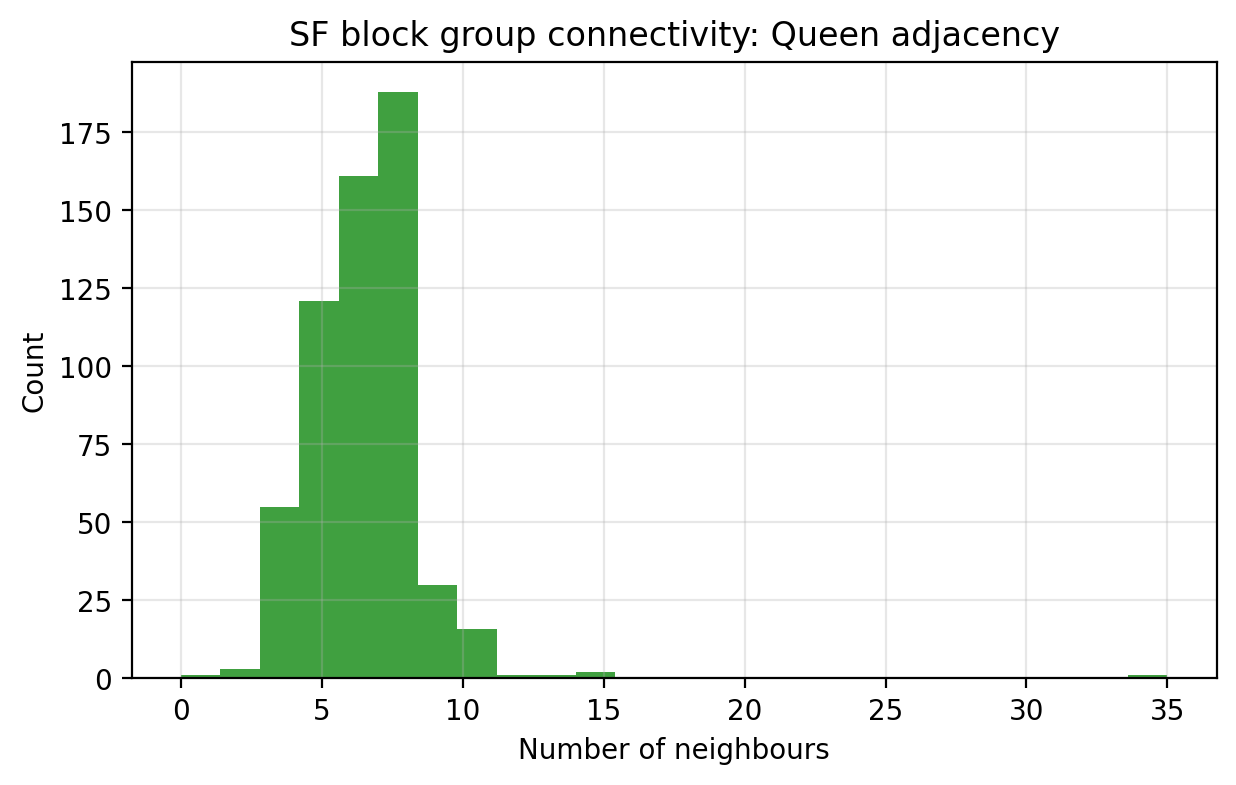

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(card.values, bins=25, facecolor="green", alpha=0.75)
plt.xlabel("Number of neighbours"); plt.ylabel("Count")
plt.title("SF block group connectivity: Queen adjacency")
plt.grid(True, alpha=0.3)
plt.show()

The bulk sits between 3 and 10, exactly as expected — and then there is a lonely bar far out to
the right at 35, and (invisibly) something at 0. Two outliers in the *graph*, not in the data.

Let us find out what they are.

In [12]:
# A block group with 0 neighbours is an "isolate": an empty row in W.
island_id = list(card[card == 0].index)[0]

print("isolate:", island_id)
print("graph components:", queen_g.n_components)

isolate: 060759804011
graph components: 2


An **isolate** has an empty row in $W$. It has no neighbours to average over, so its spatial lag
$Wy$ is undefined — there is nothing to lag. It is also why the graph reports **2 components**: the
city plus this one detached piece, with no path between them.

Which place is it?

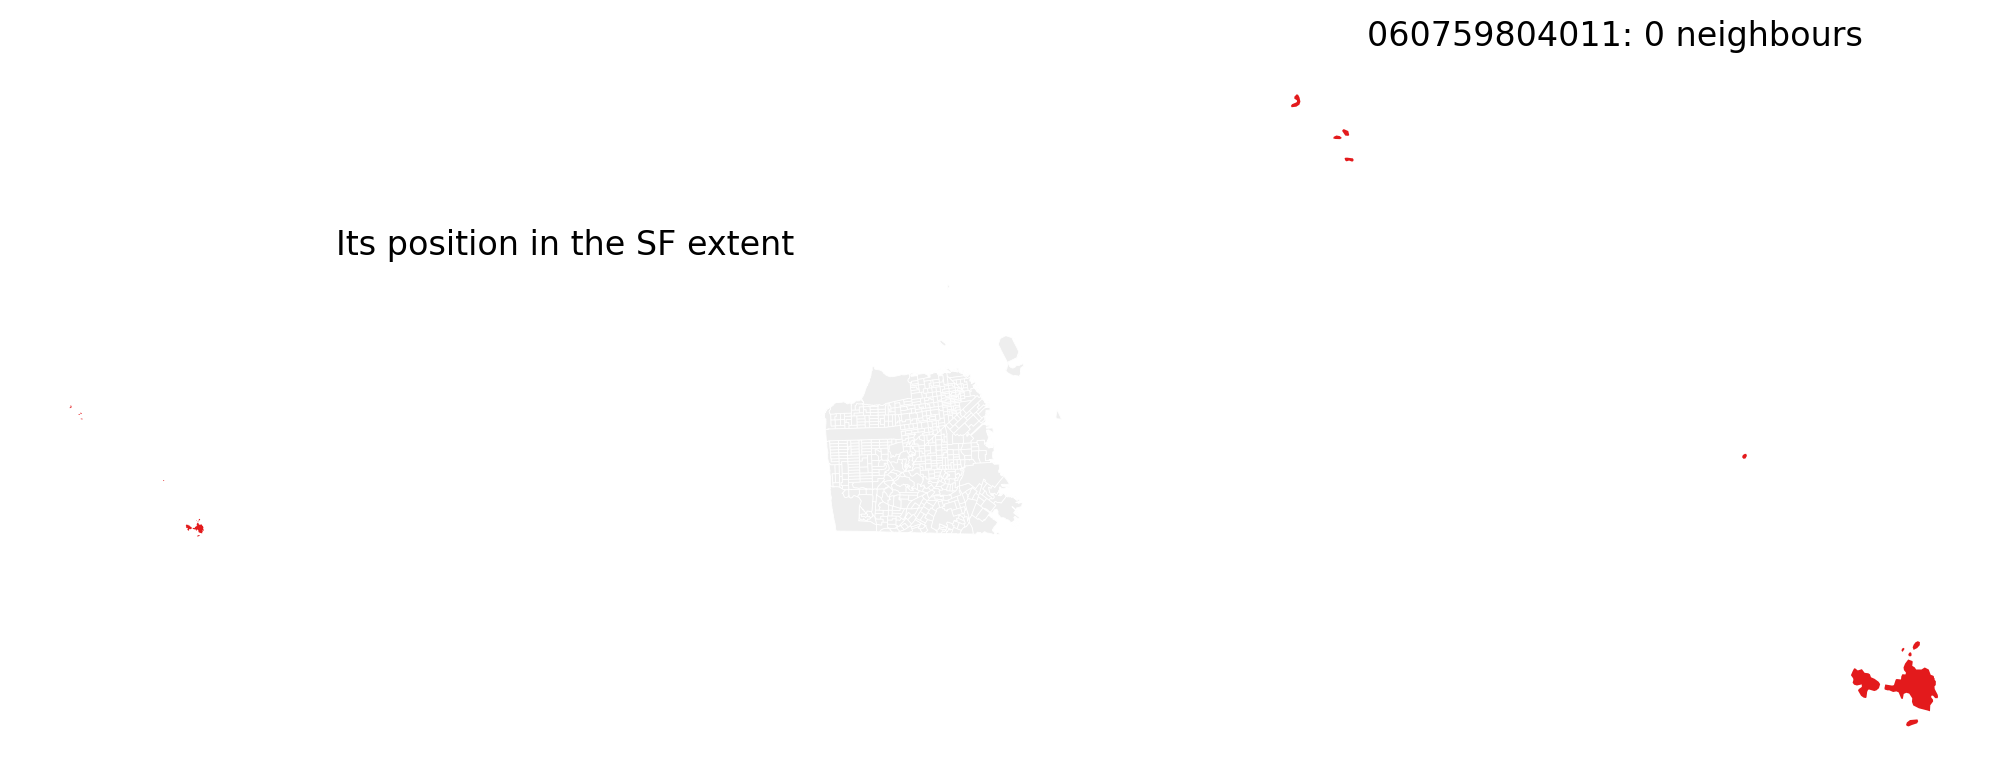

In [13]:
f, ax = plt.subplots(1, 2, figsize=(11, 4))

gdf.plot(ax=ax[0], color="#eeeeee", edgecolor="white", linewidth=0.3)
gdf.loc[[island_id]].plot(ax=ax[0], color="#e31a1c")
ax[0].set_title("Its position in the SF extent")

gdf.loc[[island_id]].plot(ax=ax[1], color="#e31a1c")
ax[1].set_title(f"{island_id}: 0 neighbours")

for a in ax: a.set_axis_off()
plt.tight_layout(); plt.show()

**The Farallon Islands** — a cluster of uninhabited rocks about 30 miles off the coast that are,
administratively, part of San Francisco. The left panel shows why the graph has two components: it
is nowhere near the rest of the city.

It is not a neighbourhood, essentially nobody lives there, and it cannot participate in a spatial
model. **Remove it.**

In [14]:
# Now the opposite extreme.
park_id = list(card[card == card.max()].index)[0]

print("most connected:", park_id, "with", card.max(), "neighbours")

most connected: 060759803001 with 35 neighbours


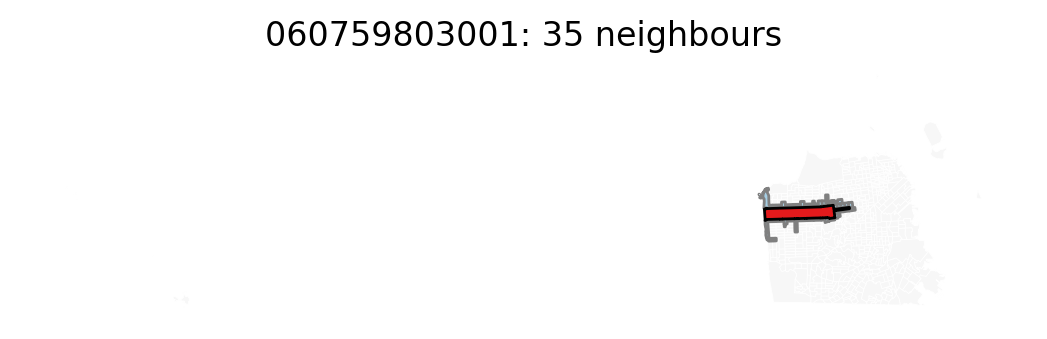

In [15]:
f, ax = plt.subplots(figsize=(6.5, 5))

gdf.plot(ax=ax, color="#f7f7f7", edgecolor="white", linewidth=0.3)
gdf.loc[list(queen_g[park_id].index)].plot(ax=ax, color="#a6cee3", edgecolor="grey")
gdf.loc[[park_id]].plot(ax=ax, color="#e31a1c", edgecolor="k")
ax.set_title(f"{park_id}: {card.max()} neighbours")
ax.set_axis_off()
plt.show()

**Golden Gate Park.** A long, thin rectangle slicing across the width of the city, touching **35**
block groups along both of its flanks.

This is a genuine problem, for two reasons:

1. **It is a hub that short-circuits the graph.** Under row-standardisation the park's
   "neighbourhood average" is really a *city-wide* average across 35 unrelated areas. Worse, the
   park becomes a two-step bridge between block groups on *opposite sides* of the city that have
   nothing to do with each other — influence flows through it as if they were adjacent.
2. **Its rate is meaningless.** Almost nobody lives in a park, so "drunk incidents per 1,000
   residents" divides by a tiny denominator and explodes.

**Remove it** — and note the fix is *substantive*, not cosmetic: the park is not a neighbourhood.

In [16]:
# One more oddity, found by inspecting geometry types rather than the graph.
bay_islands = "060750179021"

geom = gdf.loc[bay_islands].geometry
print("geometry type:", geom.geom_type)
print("number of separate polygons:", len(geom.geoms))

geometry type: MultiPolygon
number of separate polygons: 10


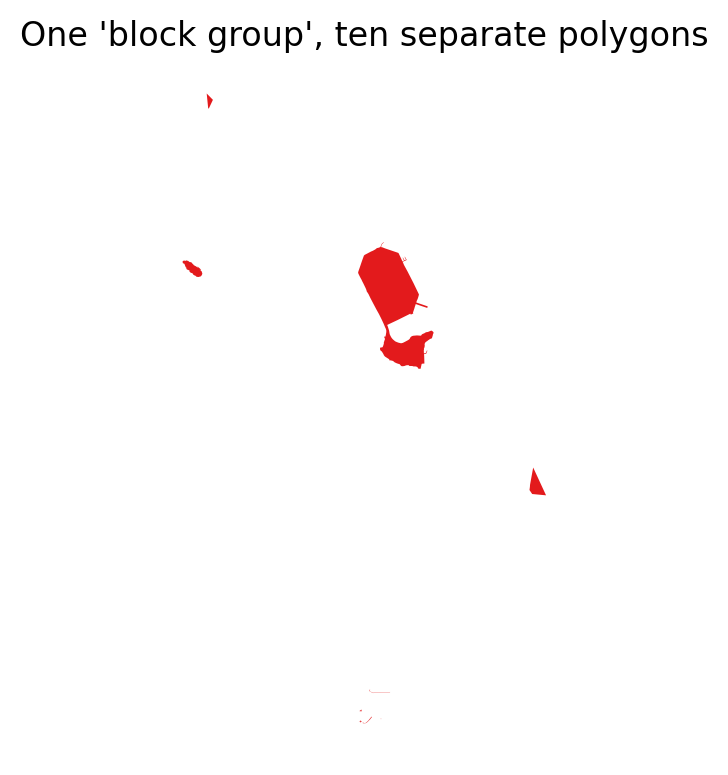

In [17]:
f, ax = plt.subplots(figsize=(5.5, 4.5))
gdf.loc[[bay_islands]].plot(ax=ax, color="#e31a1c")
ax.set_title("One 'block group', ten separate polygons")
ax.set_axis_off()
plt.show()

**The bay islands** — Alcatraz, Treasure Island and friends — bundled into a *single* block group
made of **10 disconnected polygons** scattered across the water.

Contiguity is incoherent for a unit that is not one place: whatever any one island touches gets
credited as a neighbour of *all* of them. **Remove it.**

### Removing the three

Three block groups, three different pathologies, one shared conclusion: for each, the word
"neighbour" does not mean anything. Removing them is a **documented modelling decision**, not data
cleaning to taste — and 3 of 580 is 0.5% of the sample.

In [18]:
drop = [island_id, park_id, bay_islands]
gdf  = gdf.drop(index=drop)

print("dropped:", drop)
print("remaining block groups:", len(gdf))

dropped: ['060759804011', '060759803001', '060750179021']
remaining block groups: 577


In [19]:
# Rebuild the graph on the cleaned frame -- never reuse a graph built on dropped rows.
queen_g = Graph.build_contiguity(gdf, rook=False)

print("isolates :", len(queen_g.isolates))
print("components:", queen_g.n_components)
print("median neighbours:", int(queen_g.cardinalities.median()))

isolates : 0
components: 1
median neighbours: 6


**577 block groups, zero isolates, one connected component.** Every unit now has neighbours, and
influence can flow across the whole city — a graph the models below can actually use.

**Lesson —** audit $W$ before modelling. A histogram of neighbour counts plus a check for isolates
and components costs a minute and catches the units where "neighbour" is a fiction. Report what you
dropped and why.

# 4. From links to weights

The graph says *who* is a neighbour. The **weights** say *how much each neighbour counts*.

PySAL builds weights as **binary** by default: every neighbour gets a 1. That has a subtle flaw —
the spatial lag $Wy$ becomes a **sum**, so a block group with 10 neighbours gets a lag ten times
larger than one with a single neighbour. The lag would then measure *how connected you are* rather
than *what your surroundings look like*.

In [20]:
wb = queen_g.to_W()          # bridge the Graph to the W object spreg expects

print("binary weights for", bg)
print(wb[bg])

binary weights for 060750103003
{'060750102002': 1, '060750103002': 1, '060750107001': 1, '060750107002': 1, '060750108001': 1, '060750109001': 1, '060750109002': 1}


Every neighbour carries a weight of 1, and they sum to the neighbour count. Now
**row-standardise**: divide each row by its number of neighbours.

In [21]:
w = queen_g.to_W()
w.transform = "r"            # row-standardise: each row now sums to 1

print("row-standardised weights for", bg)
print({k: round(v, 3) for k, v in w[bg].items()})
print("row sum:", round(sum(w[bg].values()), 3))

row-standardised weights for 060750103003
{'060750102002': 0.143, '060750103002': 0.143, '060750107001': 0.143, '060750107002': 0.143, '060750108001': 0.143, '060750109001': 0.143, '060750109002': 0.143}
row sum: 1.0


Each of the 7 neighbours now carries $1/7 \approx 0.143$ of the vote, and the row sums to exactly
**1**. This is what makes the spatial lag $Wy$ the **neighbourhood average** — directly comparable
across block groups regardless of how many neighbours each has, and what makes $\rho$ interpretable
as "how much of the neighbourhood average carries over".

Let us look at an actual lag value.

In [22]:
lag_values = w.sparse @ gdf[YVar].values        # Wy: the neighbourhood average
i = list(gdf.index).index(bg)

print(f"block group {bg}")
print(f"  own drunk rate            : {gdf[YVar].iloc[i]:.2f} per 1,000")
print(f"  neighbourhood average (Wy): {lag_values[i]:.2f} per 1,000")

block group 060750103003
  own drunk rate            : 2.68 per 1,000
  neighbourhood average (Wy): 2.09 per 1,000


That is the entire idea in two numbers: this block group records **2.68** incidents per 1,000, and
its neighbours average **2.09**. $Wy$ is just "what the surroundings look like" — a new variable we
can now put into a regression, or correlate with $y$ to test for clustering.

**Lesson —** row-standardise contiguity weights: it turns $Wy$ from a connectivity-dependent sum
into a comparable neighbourhood average.

# 5. Exploratory analysis

Three questions before fitting anything: does bar density track drunk incidents at all, is the
outcome spatially patterned, and are the covariates tangled up with one another?

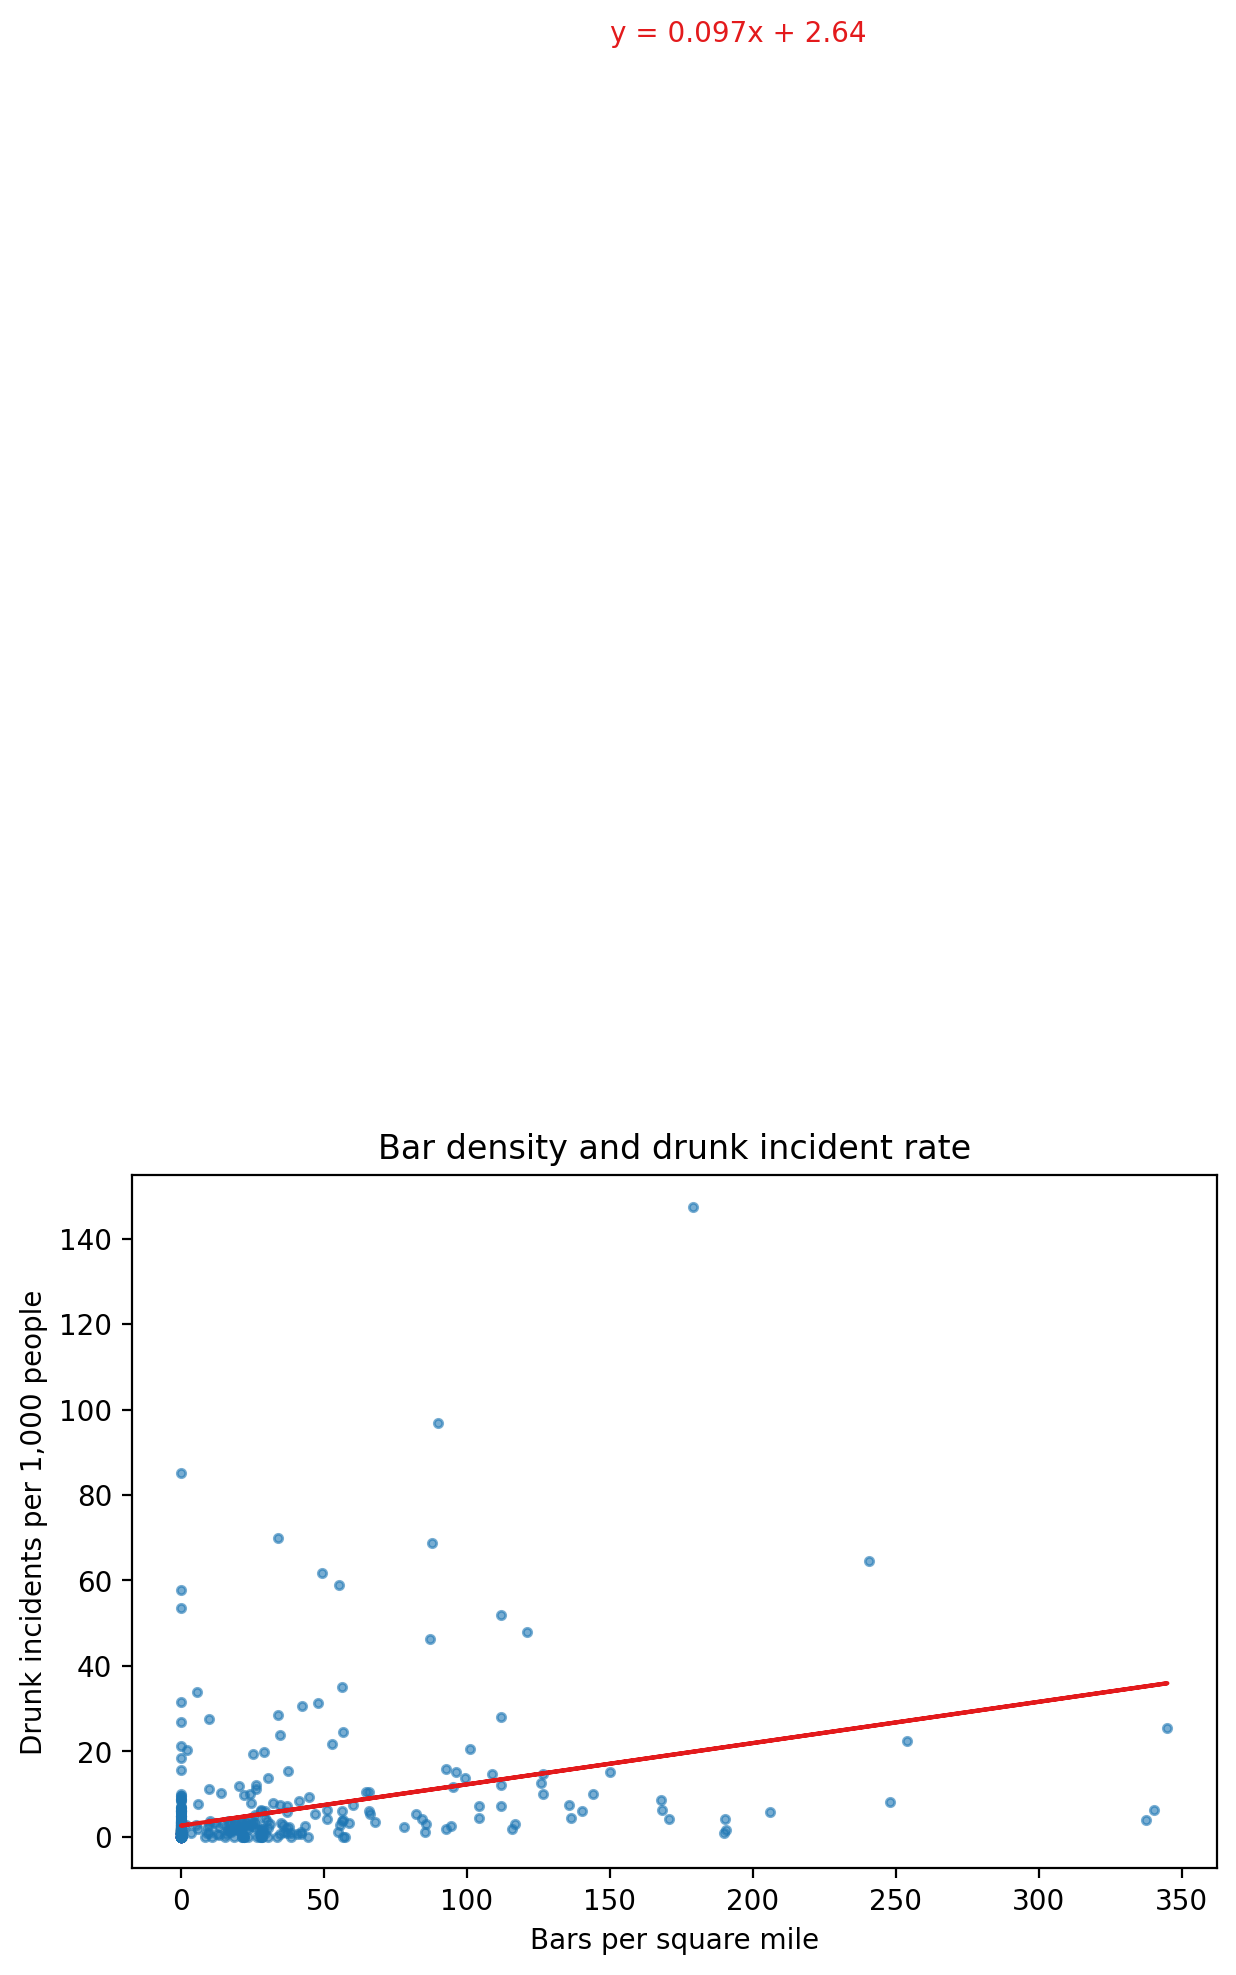

In [23]:
x, y = gdf["BarPSqMi"], gdf[YVar]
m, b_ = np.polyfit(x, y, 1)                 # simple least-squares line

plt.figure(figsize=(7, 4.5))
plt.plot(x, y, ".", alpha=0.6)
plt.plot(x, m * x + b_, "-", color="#e31a1c")
plt.xlabel("Bars per square mile"); plt.ylabel("Drunk incidents per 1,000 people")
plt.title("Bar density and drunk incident rate")
plt.text(150, 420, f"y = {m:.3f}x + {b_:.2f}", color="#e31a1c")
plt.show()

A clear **positive** slope: denser bars, more drunk incidents. Also visible is the skew we met in
the summary — a handful of block groups tower over the rest, and they will have real leverage on
the fitted line.

This is suggestive, not evidence. It ignores poverty, retail density and — crucially — space.

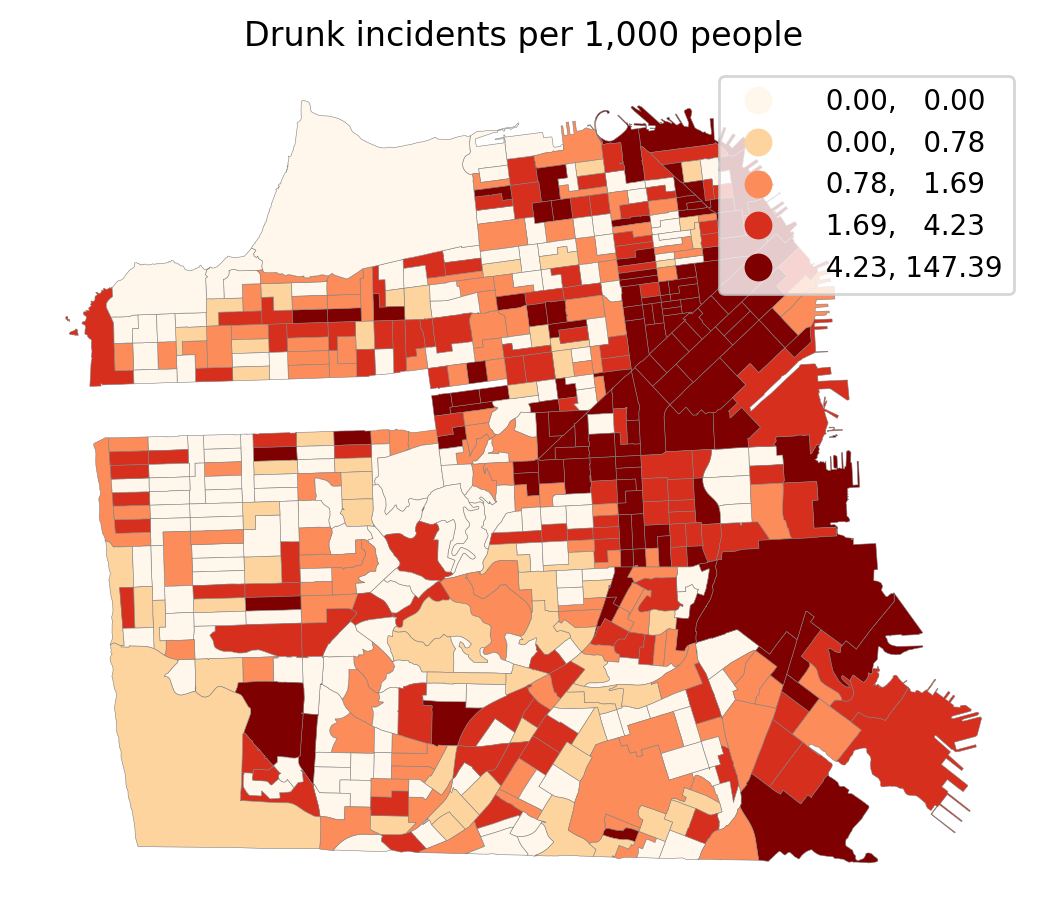

In [24]:
f, ax = plt.subplots(figsize=(6.5, 6.5))
gdf.plot(ax=ax, column=YVar, scheme="quantiles", k=5, cmap="OrRd",
         edgecolor="grey", linewidth=0.2, legend=True)
ax.set_title("Drunk incidents per 1,000 people")
ax.set_axis_off()
plt.show()

The map is emphatically **not random**. The east of the city — around Market Street, the
nightlife core — glows, while the residential west is quiet. Like sits next to like: exactly the
visual signature of **spatial autocorrelation**.

Eyeballing a map is not a test, though. Quantify it.

In [25]:
np.random.seed(SEED)
mi = esda.Moran(gdf[YVar], w, permutations=999)

print(f"Global Moran's I = {mi.I:.3f}")
print(f"pseudo p-value   = {mi.p_sim}   (999 permutations)")

Global Moran's I = 0.384
pseudo p-value   = 0.001   (999 permutations)


**Moran's I = 0.384, $p_{sim} = 0.001$.** The clustering is real: out of 999 random reshufflings
of the values across block groups, none produced an $I$ as extreme as the observed one.

**But this does not yet justify a spatial model.** A clustered outcome may simply mean the *causes*
are clustered — bars and poverty are themselves concentrated in the east. If the covariates explain
the pattern, the residuals will come out clean and OLS is fine. The question is whether structure
**remains after** the covariates have done their work. That is a question about residuals, and we
answer it in §7.

**Lesson —** a clustered outcome is a reason to inspect the residuals, not a licence to reach
straight for a spatial model.

In [26]:
gdf[[YVar] + XVars].corr().round(2)

,DrunkP1k,pHHPov,BarPSqMi,RetailPSqMi,pMale,VacantHU
DrunkP1k,1.00,0.33,0.36,0.36,0.26,0.33
pHHPov,0.33,1.00,0.31,0.31,0.02,0.20
BarPSqMi,0.36,0.31,1.00,0.55,0.22,0.20
RetailPSqMi,0.36,0.31,0.55,1.00,0.09,0.15
pMale,0.26,0.02,0.22,0.09,1.00,0.15
VacantHU,0.33,0.20,0.20,0.15,0.15,1.00


Bar density, retail density and poverty all move together (bars–retail $r = 0.55$) — unsurprising,
since they share the same dense, central, commercial geography. Worth knowing: their coefficients
will compete to explain the same variation, so each one's estimate is "holding the others fixed",
which in a city where they co-occur is a somewhat artificial thought experiment.

# 6. The model families — a taxonomy

Before fitting, know the menu. A spatial regression can carry up to **three** distinct spatial
terms (LeSage & Pace, 2009; Elhorst, 2014), and *which* ones you switch on names the model:

- **Endogenous interaction — $\rho\,WY$:** a neighbour's **outcome** affects mine. The feedback is
  *global*: a shock loops through the entire system via $(I-\rho W)^{-1}$. → **SAR (lag)**.
- **Exogenous interaction — $WX\theta$:** a neighbour's **covariate** affects my outcome. The
  spillover is *local* — one step over the graph — and the model stays **OLS-estimable**. → **SLX**.
- **Error dependence — $\lambda\,Wu$:** spatially correlated **shocks**, the fingerprint of an
  omitted spatial variable. A *nuisance*: it repairs inference but carries **no spillover to
  interpret**. → **SEM (error)**.

| Model | $\rho WY$ (endogenous) | $WX\theta$ (exogenous) | $\lambda Wu$ (error) |
|---|:---:|:---:|:---:|
| **OLS** | – | – | – |
| **SLX** | – | ✓ | – |
| **SAR** (lag) | ✓ | – | – |
| **SEM** (error) | – | – | ✓ |
| **SDM** (Durbin) | ✓ | ✓ | – |
| **SDEM** | – | ✓ | ✓ |
| **SAC / SARAR** | ✓ | – | ✓ |

### What the taxonomy means *for this question*

The abstraction becomes concrete when you ask what each term would claim about bars and drunkenness:

- **$\rho WY$ (lag)** — "this block group is rowdy **because its neighbours are rowdy**." Drinkers
  spill across boundaries; disorder propagates. Plausible.
- **$WX\theta$ (SLX)** — "this block group is rowdy **because its neighbours have bars**." Also
  plausible, and subtly different: it is the *bars* next door that matter, not the *incidents*.
- **$\lambda Wu$ (error)** — "something unmeasured — a nightlife district, a transit hub, a policing
  boundary — spans several block groups at once." Also plausible.

All three tell a credible story. Which is why we do **not** choose by taste: we let the OLS
residual diagnostics and AIC decide.

# 7. OLS with spatial diagnostics

Fit the non-spatial baseline first — always. Its **residuals** are the evidence that decides
everything: if they are spatially clean, OLS is defensible and we stop here.

In [27]:
# spreg wants plain numpy arrays: y as a column vector, X as a matrix.
Y = gdf[[YVar]].values
X = gdf[XVars].values

print("Y:", Y.shape, " X:", X.shape)

Y: (577, 1)  X: (577, 5)


In [28]:
np.random.seed(SEED)
ols = spreg.OLS(Y, X, w=w,               # passing w switches the spatial diagnostics on
                spat_diag=True, moran=True,
                name_y=YVar, name_x=XVars)

print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :    DrunkP1k                Number of Observations:         577
Mean dependent var  :      4.4709                Number of Variables   :           6
S.D. dependent var  :     11.9500                Degrees of Freedom    :         571
R-squared           :      0.2862
Adjusted R-squared  :      0.2800
Sum squared residual:     58712.2                F-statistic           :     45.7902
Sigma-square        :     102.824                Prob(F-statistic)     :   8.877e-40
S.E. of regression  :      10.140                Log likelihood        :   -2152.336
Sigma-square ML     :     101.754                Akaike info criterion :    4316.673
S.E of regression ML:     10.0873                Schwarz criterion     :    4342.820

------------------------------------------------------------

**The non-spatial story.** All five covariates are positive and significant: more bars, more
retail, more poverty, more men, more vacant housing — all associated with more drunk incidents.
`BarPSqMi` sits at **0.032** ($p = 0.007$). $R^2 = 0.286$.

Taken at face value this looks like a finished analysis. The diagnostics at the bottom of that
summary say otherwise — let us read them properly.

In [29]:
np.random.seed(SEED)
mi_ols = esda.Moran(ols.u.flatten(), w, permutations=999)

print(f"Moran's I of the OLS residuals = {mi_ols.I:.3f}")
print(f"pseudo p-value                 = {mi_ols.p_sim}")

Moran's I of the OLS residuals = 0.222
pseudo p-value                 = 0.001


**Residual Moran's I = 0.222, $p_{sim} = 0.001$.** This is the finding that reshapes the analysis.

The covariates did **not** absorb the spatial pattern. After accounting for bars, retail, poverty,
sex ratio and vacancy, what is left over *still* clusters — a block group with an
under-predicted rate sits next to other under-predicted ones. OLS's core assumption
($\text{Cov}(\varepsilon_i,\varepsilon_j)=0$) is violated, so:

- its **standard errors are wrong** (too small — the effective sample is smaller than 577), and
- if the true process contains a lag, its **coefficients are biased** too.

OLS is not defensible here. We need a spatial model.

In [30]:
diag = pd.DataFrame(
    {"statistic": [ols.lm_lag[0], ols.rlm_lag[0], ols.lm_error[0], ols.rlm_error[0]],
     "p-value":   [ols.lm_lag[1], ols.rlm_lag[1], ols.lm_error[1], ols.rlm_error[1]]},
    index=["LM-lag", "robust LM-lag", "LM-error", "robust LM-error"]).round(4)
diag

,statistic,p-value
LM-lag,102.1072,0.0000
robust LM-lag,16.9288,0.0000
LM-error,86.2167,0.0000
robust LM-error,1.0382,0.3082


**Which spatial term is missing?** The Lagrange Multiplier tests answer exactly this — and there
is a decision rule (Anselin & Rey, 2014), which you follow *in order*:

1. **Look at the plain LM tests first.** `LM-lag` = 102.1 and `LM-error` = 86.2, both $p<0.0001$.
   Both fire. They cannot discriminate — and that is expected, because each test is *sensitive to
   the other's* misspecification.
2. **When both are significant, go to the robust versions.** Each robust test controls for the
   presence of the other:
   - robust **LM-lag** = **16.93**, $p < 0.0001$ → **significant**
   - robust **LM-error** = **1.04**, $p = 0.308$ → **not significant**

The verdict is unambiguous: once you control for a possible error process, the evidence for a
**lag** survives; once you control for a possible lag, the evidence for an **error** process
evaporates. The data want $\rho WY$.

**Lesson —** do not choose a spatial model by taste. Fit OLS, test the residuals, and when both LM
tests fire, let the *robust* pair name the culprit.

# 8. Fitting the whole family, ranked by AIC

The robust LM test is one line of evidence. A second, independent one: fit **every** model on the
menu and compare them on **AIC**, which rewards fit but charges for each extra parameter — so a
richer model only wins if the data pay for it.

`slx_lags=1` adds the exogenous $WX$ block, which is what turns OLS into SLX and SAR into SDM.

In [31]:
models = {
    "OLS": spreg.OLS     (Y, X, w=w,             name_y=YVar, name_x=XVars),  # no spatial term
    "SLX": spreg.OLS     (Y, X, w=w, slx_lags=1, name_y=YVar, name_x=XVars),  # + WX
    "SAR": spreg.ML_Lag  (Y, X, w=w,             name_y=YVar, name_x=XVars),  # + rho*WY
    "SEM": spreg.ML_Error(Y, X, w=w,             name_y=YVar, name_x=XVars),  # + lambda*Wu
    "SDM": spreg.ML_Lag  (Y, X, w=w, slx_lags=1, name_y=YVar, name_x=XVars),  # + rho*WY and WX
}
print("fitted:", list(models))

fitted: ['OLS', 'SLX', 'SAR', 'SEM', 'SDM']


In [32]:
terms = {"OLS": "—", "SLX": "WX (exog.)", "SAR": "rho*WY (endog.)",
         "SEM": "lambda*Wu (error)", "SDM": "rho*WY + WX (both)"}

ladder = (pd.DataFrame([{"model": k, "spatial terms": terms[k],
                         "logL": round(m.logll, 1), "AIC": round(m.aic, 1)}
                        for k, m in models.items()])
          .set_index("model").sort_values("AIC"))
ladder

,spatial terms,logL,AIC
model,,,
SDM,rho*WY + WX (both),-2105.1,4234.2
SAR,rho*WY (endog.),-2111.1,4236.2
SEM,lambda*Wu (error),-2114.1,4240.2
SLX,WX (exog.),-2134.7,4291.5
OLS,—,-2152.3,4316.7


**Reading the ladder, top to bottom.**

- **Every spatial model beats OLS** (4316.7), and not narrowly. Space is not optional here.
- **SLX alone (4291.5) already improves on OLS by 25 AIC points.** Even a purely *exogenous*
  neighbour effect — your neighbours' *bars*, with no feedback at all — buys a lot. Space matters
  before any endogenous story is told.
- **SDM (4234.2) and SAR (4236.2) are effectively tied.** A gap of 2.0 AIC points is the
  conventional threshold for "indistinguishable". SDM fits marginally better, but spends **five
  extra parameters** ($WX$ for every covariate) to get there.
- **SEM (4240.2) trails SAR**, agreeing with the robust LM test that rejected the error story.

Two independent routes — robust LM and AIC — both land on the **lag**. Where they nearly differ,
AIC's slight nod to SDM hints that some *exogenous* spillover may also be present; the deck's
advice ("prefer Durbin when in doubt about exogenous spillovers") is the conservative call. We
proceed with **SAR** as the parsimonious model the diagnostics named, and report SDM as the
defensible alternative rather than hiding it.

**Lesson —** report the whole ladder, not just the winner: a 2-point AIC gap is a tie, and saying
so is more honest than crowning a champion.

# 9. The spatial lag model

$$Y = \rho WY + X\beta + \varepsilon$$

The neighbourhood average of the outcome, $WY$, enters as an explanatory variable in its own
right. Fit it and read the result.

In [33]:
sar = models["SAR"]
print(sar.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :    DrunkP1k                Number of Observations:         577
Mean dependent var  :      4.4709                Number of Variables   :           7
S.D. dependent var  :     11.9500                Degrees of Freedom    :         570
Pseudo R-squared    :      0.4080
Spatial Pseudo R-squared:  0.3038
Log likelihood      :  -2111.1038
Sigma-square ML     :     84.6821                Akaike info criterion :    4236.208
S.E of regression   :      9.2023                Schwarz criterion     :    4266.712

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------------

**The spatial term is large and decisive.** `W_DrunkP1k` — that is $\rho$ — comes in at **0.467**
with $z = 9.82$, overwhelmingly significant. It is *positive*, exactly as the positive residual
autocorrelation predicted: rowdy block groups sit beside rowdy block groups.

All five covariates stay positive and significant, but every coefficient **shrinks**. That is not a
coincidence, and it is the next thing to examine.

In [34]:
coefs = pd.DataFrame({"OLS": ols.betas[1:, 0],
                      "SAR": sar.betas[1:len(XVars)+1, 0]}, index=XVars)
coefs["% change"] = (100 * (coefs["SAR"] - coefs["OLS"]) / coefs["OLS"]).round(1)
coefs.round(4)

,OLS,SAR,% change
pHHPov,0.1900,0.1033,-45.6
BarPSqMi,0.0319,0.0240,-24.9
RetailPSqMi,0.0151,0.0120,-20.3
pMale,0.2901,0.1762,-39.3
VacantHU,0.3683,0.2809,-23.7


**This is what omitted-variable bias looks like.** Every coefficient falls once $\rho WY$ enters.
For `BarPSqMi`: **0.0319 → 0.0240**, a **25% reduction**.

Why? OLS had no way to express "this block group is rowdy because its neighbours are". That
influence had to go *somewhere*, so it was absorbed by whatever covariate correlated with it —
and bar density, being spatially clustered, took the credit. Once the model can attribute
neighbourhood spillover to the spillover term, bar density's own contribution is revealed to be
smaller.

The OLS estimate was not merely imprecise. It was **biased upward** — it would have overstated the
effect of a licensing decision by a quarter.

In [35]:
np.random.seed(SEED)
mi_sar = esda.Moran(sar.u.flatten(), w, permutations=999)

print(f"OLS residual Moran's I = {mi_ols.I:.3f}  (p_sim = {mi_ols.p_sim})")
print(f"SAR residual Moran's I = {mi_sar.I:.3f}  (p_sim = {mi_sar.p_sim})")

OLS residual Moran's I = 0.222  (p_sim = 0.001)
SAR residual Moran's I = 0.003  (p_sim = 0.388)


**Did the fix actually work?** Yes — and this check is not optional.

Residual Moran's I collapses from **0.222 ($p = 0.001$)** to **0.003 ($p \approx 0.39$)**:
indistinguishable from random. The $\rho WY$ term has **absorbed** the spatial structure it was
hired to handle. There is no clustering left for a further spatial term to explain, which also
retroactively confirms the robust LM test's verdict — a lag was the right diagnosis.

Had the residuals stayed clustered, we would have had to revisit $W$, reconsider SEM/SDM, or accept
that a missing covariate was driving the pattern.

**Lesson —** always re-test the residuals after fitting. A spatial model that leaves the
autocorrelation in place has not earned its extra parameters.

# 10. Interpretation — why $\beta$ is *not* the effect

We have a fitted model and a significant bar-density coefficient of **0.024**. The temptation is to
report it and stop. That would be wrong.

In a standard linear regression, changing a covariate at one observation affects the outcome **only
at that observation**. This is *not* true once $\rho WY$ is in the equation: drunk incidents here
depend on incidents next door, which depend on incidents here. A change therefore **propagates
through the system and partly loops back**.

So $\beta = 0.024$ does not answer "what happens if this block group gets more bars?" — it is one
ingredient in that answer. The next six steps build the real one, one number at a time.

### Step 1 — the two ingredients

Everything below is built from just two things in the fitted model: the **slope coefficients**
$\beta$, and the **spatial autoregressive parameter** $\rho$.

In [36]:
# betas layout: [CONSTANT, <the five XVars>, rho]  -- rho is always last.
b = sar.betas[1:len(XVars)+1, 0]        # the five slope coefficients

pd.Series(b, index=XVars).round(4)

pHHPov         0.1033
BarPSqMi       0.0240
RetailPSqMi    0.0120
pMale          0.1762
VacantHU       0.2809
dtype: float64

In [37]:
rho = sar.betas[-1, 0]                  # the spatial autoregressive parameter
print("rho =", round(rho, 4))

rho = 0.4666


$\rho \approx 0.467$, and **positive**: about 47% of the neighbourhood's average rate carries over.
That number is the engine of everything that follows. If $\rho$ were 0, the model would collapse to
OLS, nothing would propagate, and $\beta$ *would* be the effect.

Note we deliberately exclude the **constant** from `b`. An intercept has no "effect" to
decompose — asking how a constant spills over is meaningless. (This is a trap: it is easy to slice
the coefficient vector carelessly and end up reporting impacts for the intercept.)

### Step 2 — the total effect: $\beta/(1-\rho)$

Because the effect keeps bouncing around the system, the **total** effect of a covariate is larger
than $\beta$. It has a famously simple closed form (Kim, Phipps & Anselin, 2003):

$$\text{Total effect} = \frac{\beta}{1-\rho}$$

The factor $1/(1-\rho)$ is the **spatial multiplier**: the sum of an infinite series of ever-weaker
ripples. Compute it.

In [38]:
total_multiplier = 1 / (1 - rho)
print("spatial multiplier 1/(1-rho) =", round(total_multiplier, 4))

spatial multiplier 1/(1-rho) = 1.8748


**1.875.** Every effect in this model is ~87% larger than its coefficient suggests — because with
$\rho=0.467$, roughly half of any change is passed to the neighbours, who pass roughly half of
*that* on, and so on until the series converges.

In [39]:
b_total = b / (1 - rho)

pd.DataFrame({"beta": b, "total effect": b_total}, index=XVars).round(4)

,beta,total effect
pHHPov,0.1033,0.1937
BarPSqMi,0.0240,0.0449
RetailPSqMi,0.0120,0.0225
pMale,0.1762,0.3303
VacantHU,0.2809,0.5267


For **`BarPSqMi`**: $\beta = 0.0240$, but the **total** effect is **0.0449** — nearly double.
Reporting the bare coefficient would describe barely half of what bar density actually does to the
city.

This formula is **exact**, not an approximation. Step 4 proves it.

### Step 3 — splitting the total: the naive way, and its trap

The total splits into two conceptually different parts:

- **Direct** — the effect on a block group's *own* rate of changing its *own* bar density.
- **Indirect** (the spillover) — the effect on *other* block groups.

The obvious split is to say the direct effect is just $\beta$ (the coefficient *is* the own-area
effect, surely?) and call whatever is left over indirect:

In [40]:
direct_naive   = b                      # "the coefficient is the own-area effect"
indirect_naive = b_total - b            # "whatever is left must be the spillover"

pd.DataFrame({"Direct": direct_naive, "Indirect": indirect_naive, "Total": b_total},
             index=XVars).round(4)

,Direct,Indirect,Total
pHHPov,0.1033,0.0904,0.1937
BarPSqMi,0.0240,0.0210,0.0449
RetailPSqMi,0.0120,0.0105,0.0225
pMale,0.1762,0.1541,0.3303
VacantHU,0.2809,0.2458,0.5267


**This is the trap, and it is worth understanding precisely.**

Setting `direct = beta` assumes the effect leaves the block group and **never comes back**. But it
does come back. Trace it: more bars here → more incidents here → more incidents *next door* (that
is $\rho WY$ working on the neighbour) → but *our* rate depends on *their* rate too, so their
increase pushes **ours** up again.

That returning piece is genuinely a **direct** effect — it lands back on the very block group that
gained the bars — yet the naive split has silently filed it under *indirect*.

So the naive `Direct` is **too small** and its `Indirect` is **too big**. Note the `Total` is
unaffected: the two errors are equal and opposite, so they cancel. That is precisely why this
mistake is so easy to miss — the headline number looks right.

### Step 4 — measuring the feedback loop

To split the total *correctly* we need the object the multiplier was hiding: the **spatial
multiplier matrix**

$$M=(I-\rho W)^{-1}=I+\rho W+\rho^{2}W^{2}+\rho^{3}W^{3}+\cdots$$

Read the series left to right and it tells the whole story:

- $I$ — the change hits the block group itself,
- $\rho W$ — then its neighbours,
- $\rho^{2}W^{2}$ — then neighbours-of-neighbours,
- each ripple weaker than the last, because $|\rho| < 1$.

Now the crucial detail: $W^{2}$ contains paths of length 2, and **some of those return to where
they started** ($i \to j \to i$). So $W^{2}$, $W^{4}$, … have **non-zero diagonals**. The diagonal
of $M$ is therefore *bigger than 1* — and the excess is exactly the feedback the naive split threw
away. Hence (LeSage & Pace, 2009):

- **Direct** = mean of the **diagonal** of $M$, times $\beta$ — own effect *including* feedback.
- **Total** = mean of the **row sums** of $M$, times $\beta$.
- **Indirect** = total − direct.

In [41]:
W_dense = w.full()[0]                              # W as a dense array
M = np.linalg.inv(np.eye(w.n) - rho * W_dense)     # M = (I - rho*W)^-1

print("M is", M.shape, "- one row and column per block group")

M is (577, 577) - one row and column per block group


In [42]:
direct_multiplier = np.diag(M).mean()      # average of the diagonal: own + feedback
rowsum_multiplier = M.sum(axis=1).mean()   # average of the row sums: everything

print("average diagonal of M =", round(direct_multiplier, 4))
print("average row sum of M  =", round(rowsum_multiplier, 4))
print("1/(1-rho) from Step 2 =", round(total_multiplier, 4))

average diagonal of M = 1.0454
average row sum of M  = 1.8748
1/(1-rho) from Step 2 = 1.8748


**Two things just happened — both important.**

1. **The average row sum equals $1/(1-\rho)$ exactly** (1.8748 both ways). That is not a
   coincidence; it is a proof. The simple Step-2 formula was **never an approximation** — it is the
   row-sum of the multiplier matrix in closed form. Good: the total effect stands.

2. **The average diagonal is 1.0454, not 1.0000.** There it is — the feedback, measured. For every
   unit of effect a block group sends out into the city, about **0.045 returns to it**. The naive
   split assumed this was exactly 1.0 and lost that 4.5%.

Now redo the split with the measured diagonal instead of the assumption.

In [43]:
direct   = b * direct_multiplier     # own area, INCLUDING the returning feedback
total    = b * rowsum_multiplier     # everything (same as Step 2)
indirect = total - direct            # the genuine spillover to others

impacts = pd.DataFrame({"Direct": direct, "Indirect": indirect, "Total": total},
                       index=XVars).round(4)
impacts

,Direct,Indirect,Total
pHHPov,0.1080,0.0857,0.1937
BarPSqMi,0.0251,0.0199,0.0449
RetailPSqMi,0.0126,0.0100,0.0225
pMale,0.1842,0.1461,0.3303
VacantHU,0.2937,0.2330,0.5267


Compare against Step 3. For `BarPSqMi`, direct moves **0.0240 → 0.0251** and indirect
**0.0210 → 0.0199**. The difference *is* the feedback loop, now filed where it belongs. The totals
are untouched, as predicted.

Both conventions have names, and `spreg` will compute them for you:
`GM_Lag(..., spat_impacts=["simple", "full"])` returns **`simple`** (the Step-3 naive split, direct
multiplier pinned at 1.0) and **`full`** (the Step-4 split, direct multiplier 1.045). We did it by
hand so the arithmetic is visible — in practice, ask for **`full`**.

In [44]:
ratios = {v: round(indirect[i] / direct[i], 3) for i, v in enumerate(XVars)}
print("indirect / direct ratio, per covariate:")
for k, v in ratios.items():
    print(f"  {k:12s} {v}")

indirect / direct ratio, per covariate:
  pHHPov       0.793
  BarPSqMi     0.793
  RetailPSqMi  0.793
  pMale        0.793
  VacantHU     0.793


**A limitation worth carrying away.** The ratio is **identical (0.793) for every covariate** — not
approximately, exactly. This is not a finding about San Francisco; it is an artefact of the model.
A single global $\rho$ forces *every* variable to spill over in the *same* proportion.

Is that plausible here? Probably not. A bar draws drinkers *across* block-group boundaries in a way
that a block group's poverty rate simply does not. If you believe bars and poverty should spill
differently, SAR cannot express it — and that is a substantive argument for **SDM**, which gives
each covariate its own $WX$ term and which AIC already ranked first.

### Step 5 — reading the impacts in plain words

Numbers mean nothing until you can say them out loud. Take **`BarPSqMi`** — direct **0.0251**,
indirect **0.0199**, total **0.0449**:

- **Direct = 0.025.** Add bars to *one* block group and its *own* drunk rate rises by 0.025 per
  1,000 residents for each additional bar per square mile — feedback included, which is why it
  slightly exceeds $\beta = 0.024$.
- **Indirect = 0.020.** That same increase **also** raises *other* block groups' rates, by 0.020 in
  total across the city. Drinkers do not respect block-group boundaries: some of the incidents land
  next door.
- **Total = 0.045.** Raise bar density **everywhere** and a typical block group's rate rises by
  0.045 — its own effect **plus** every spillover it receives from others.

Put concretely: **10 more bars per square mile ⇒ about 0.45 more drunk incidents per 1,000
residents — and 44% of that happens *outside* the block group that gained the bars.**

That externality is invisible to OLS and invisible to $\beta$. It is also exactly the number a
licensing authority needs, because it is the part of the cost that the neighbourhood granting the
licence does not bear.

**Lesson —** report **impacts, not raw $\beta$**. Here the spillover is not a statistical
technicality — it *is* the policy finding.

### Step 6 — from impacts to elasticities

An impact of 0.045 is still hard to feel. Is 10 bars per square mile a lot? Is half an incident per
1,000 people big or small? Without knowing the scale of the underlying data, we cannot say.

**Elasticities** strip the units out by asking a **percentage** question of the data's own means:

> if bar density rose **10%** above its citywide average, what **%** change in the drunk incident
> rate should we expect?

In [45]:
mean_bars  = gdf["BarPSqMi"].mean()
mean_drunk = gdf[YVar].mean()

print(f"mean bar density = {mean_bars:.2f} bars per sq mile")
print(f"mean drunk rate  = {mean_drunk:.2f} incidents per 1,000 people")

mean bar density = 18.91 bars per sq mile
mean drunk rate  = 4.47 incidents per 1,000 people


In [46]:
bars_idx  = XVars.index("BarPSqMi")

bars_rise  = 0.10 * mean_bars                   # a 10% increase over the mean
drunk_chg  = bars_rise * b_total[bars_idx]      # expected change -- using the TOTAL effect
pct_change = drunk_chg / mean_drunk             # as a share of the mean rate

print(f"a 10% rise in bar density = +{bars_rise:.2f} bars per sq mile")
print(f"  -> expected change in drunk rate: {drunk_chg:.3f} per 1,000")
print(f"  -> as a % of the mean rate      : {100*pct_change:.1f}%")

a 10% rise in bar density = +1.89 bars per sq mile
  -> expected change in drunk rate: 0.085 per 1,000
  -> as a % of the mean rate      : 1.9%


**A 10% increase in average bar density is associated with roughly a 1.9% increase in the drunk
incident rate**, spillovers included.

That is a sentence you can put in front of a city council: no units to explain, no coefficients to
interpret, no matrix algebra. It is the same model, the same data and the same $\rho$ — just
expressed in a currency a non-specialist can price.

Note we used the **total** effect deliberately. An elasticity built on $\beta$ alone would report
roughly half this figure and would understate the citywide consequence of a licensing decision.

**Lesson —** in a spatial-lag model the answer is three numbers, not one: *direct* (own area, with
feedback), *indirect* (spillover to others), and *total* (both). Get the total from
$\beta/(1-\rho)$, split it with the multiplier's diagonal — never by assuming direct $= \beta$ —
and convert to an elasticity when the result needs to travel outside the seminar room.

# 11. Caveats — what this analysis does *not* license

The spatial machinery above is sound. The claims you can hang on it need care.

- **This is not causal.** Bars are *sited* where nightlife already is. We measure association, not
  the effect of *opening* a bar. Reverse causation (rowdy areas attract bars) and selection are
  wide open, and no amount of spatial econometrics closes them.
- **The outcome is a skewed count rate** — median 1.1, max 600, over a quarter zeros — fitted with a
  linear model. The spatial conclusions are robust, but a **spatial Poisson or negative-binomial**
  model is the statistically correct home for this outcome. The source analysis says the same.
- **We deleted three block groups.** Defensible and documented (an isolate, a 35-neighbour park hub,
  a multipart island set), but it *was* a researcher decision that moved the numbers.
- **$W$ is an assumption.** Queen contiguity was a choice. The honest robustness check is to re-run
  under Rook, KNN and distance bands and report whether the conclusions survive.
- **SAR forces one spillover ratio for all covariates** (Step 4) — and SDM was nearly tied on AIC.
  A fuller treatment would report SDM alongside.

**Lesson —** an honest write-up states the model *and* its licence: what was assumed, what was
dropped, and which question the estimate can and cannot answer.

# Recap — the workflow, end to end

| Step | What we did | Result |
|---|---|---|
| **Graph** | Queen contiguity, then audited it | dropped Farallon (0 nbrs), Golden Gate Park (35, a hub), bay islands (10 polygons) → **577 BGs, 1 component** |
| **Weights** | row-standardised | $Wy$ = the neighbourhood average |
| **Explore** | Moran's I on the outcome | $I = 0.384$ ($p = 0.001$) — clustered, but not yet a licence |
| **Diagnose** | OLS + spatial diagnostics | residual $I = 0.222$ ($p=0.001$) → OLS rejected; robust LM-lag **16.93** vs LM-error **1.04** → **lag** |
| **Select** | whole family by AIC | SDM 4234.2 ≈ **SAR 4236.2** < SEM 4240.2 < SLX 4291.5 < OLS 4316.7 |
| **Fit** | SAR | $\rho = 0.467$ ($z=9.82$); bars **0.0319 → 0.0240**, a 25% OLS bias |
| **Validate** | residual Moran's I on SAR | **0.003** ($p\approx0.39$) — dependence absorbed |
| **Interpret** | impacts via the multiplier | bars: direct **0.025**, indirect **0.020**, total **0.045** — 44% spills over |
| **Communicate** | elasticity | +10% bar density ⇒ **+1.9%** drunk incidents |

The through-line: **detect → diagnose → select → validate → interpret**. Every spatial term was
earned from evidence rather than assumed; the model was checked *after* fitting, not only before;
and the headline is reported as an impact and an elasticity, because the coefficient alone would
have understated the effect by half and hidden the spillover entirely.

> **References.** Anselin, L. (1988), *Spatial Econometrics: Methods and Models*. — Anselin, L. &
> Rey, S. J. (2014), *Modern Spatial Econometrics in Practice* (LM decision rule). — LeSage, J. P. &
> Pace, R. K. (2009), *Introduction to Spatial Econometrics* (impacts, SDM). — Elhorst, J. P. (2014),
> *Spatial Econometrics: From Cross-Sectional Data to Spatial Panels* (the $WY$/$WX$/$Wu$ taxonomy). —
> Kim, C.-W., Phipps, T. T. & Anselin, L. (2003), *Measuring the benefits of air quality improvement*,
> JEEM 45:24–39 (the spatial multiplier). — Gaidus, A., *Modeling San Francisco Crime Rates: A
> Spatial Econometric Approach* (the example and the data).